In [1]:
%load_ext autoreload
%autoreload 2

In [61]:
import json

import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from platform_stabilization.chi_functions import ChiFunctionFactory
from platform_stabilization.controllers import FirstStageController
from platform_stabilization.early_stopping_criterions import make_h_trig_condition
from platform_stabilization.systems import System

In [49]:
sns.set_theme(
    context="notebook", 
    style="darkgrid",
)

In [80]:
controller_parameters_path = "/home/jovyan/people/makarov/platform-stabilization/saved_controllers/alpha_max_3.0/parameters/0.json"

with open(controller_parameters_path, "r") as f:
    controller_parameters = json.load(f)

controller_parameters


{'F_0': 32.118207621393545,
 'F_theta': 16.685625540796657,
 'mu': 0.4256327300240895,
 'h_trig': 4.897920010875376}

In [81]:
object_path = "/home/jovyan/people/makarov/platform-stabilization/saved_objects/0.json"

with open(object_path, "r") as f:
    object = json.load(f)

print(object["parameters"])
print(object["initial_conditions"])

{'M': 1.4591401976868257, 'J': 0.5375161328340003, 'L_1': 0.8348161072232341, 'L_2': 0.9125439775536789, 'alpha_1': 0.2727642604793905, 'alpha_2': 0.2633753395982795, 'L': 0.8597078011838795}
{'theta': 0.2972228714587126, 'h': 0, 'd_h': 0, 'd_theta': 0}


In [82]:
test_system = System(**object["parameters"])

test_system.__dict__

{'_M': 1.4591401976868257,
 '_J': 0.5375161328340003,
 '_L1': 0.8348161072232341,
 '_L2': 0.9125439775536789,
 '_alpha_1': 0.2727642604793905,
 '_alpha_2': 0.2633753395982795}

In [83]:
y_0 = np.array(
    [
		object["initial_conditions"]["theta"],
		object["initial_conditions"]["d_theta"],
		object["initial_conditions"]["h"],
		object["initial_conditions"]["d_h"],
	]
)

y_0

array([0.29722287, 0.        , 0.        , 0.        ])

In [84]:
chi = ChiFunctionFactory.construct("tanh").chi
chi

<ufunc 'tanh'>

In [85]:
controller_1 = FirstStageController(
    F_theta=controller_parameters["F_theta"],
    F_0=controller_parameters["F_0"],
    theta_0=object["initial_conditions"]["theta"],
    i=1,
    chi=chi,
)

controller_2 = FirstStageController(
    F_theta=controller_parameters["F_theta"],
    F_0=controller_parameters["F_0"],
    theta_0=object["initial_conditions"]["theta"],
    i=2,
    chi=chi,
)

In [86]:
t_span = [0, 10]

In [87]:
h_trig_criterion = make_h_trig_condition( 
    h_trig=controller_parameters["h_trig"],
    L_1=object["parameters"]["L_1"],
    L_2=object["parameters"]["L_2"],
    alpha_1=object["parameters"]["alpha_1"],
    alpha_2=object["parameters"]["alpha_2"],
)

In [88]:
t, y = test_system.simulate(
    controller_1,
    controller_2,
    y_0,
    t_span,
    h_trig_criterion,
)

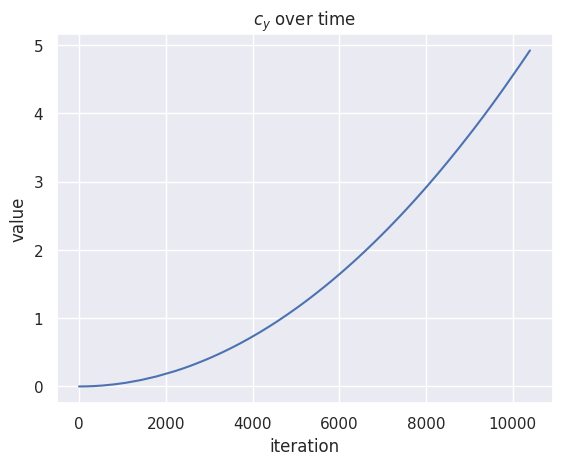

In [89]:
plt.plot(y[2])

plt.title(r"$c_y$ over time")

plt.ylabel("value")
plt.xlabel("iteration")

plt.show()

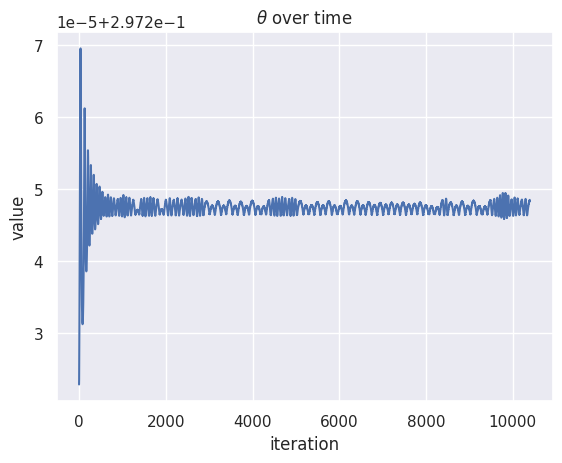

In [90]:
plt.plot(y[0])

plt.title(r"$\theta$ over time")

plt.ylabel("value")
plt.xlabel("iteration")

plt.show()

In [91]:
t[-1]

np.float64(0.5361996019702625)